# Risk is the Other Side of Return

Welcome to Workshop 4.2! In our previous workshop, we learned how to engineer multiple alpha factors and blend them into a composite alpha score.

Finding good signals feels exhilarating. However, generating alpha is only half the battle in quantitative finance. A strategy with brilliant stock-picking abilities can still blow up if it takes reckless risks. If a fund suffers a 50 percent drawdown, it needs a 100 percent gain just to break even.

As professional quants often say: alpha is how we eat, but risk management is how we survive.

In this workshop, we will transform raw alpha signals into disciplined investment portfolios. We will start with a simple equal-weight baseline, implement volatility targeting to balance risk contributions, apply correlation penalties, and enforce hard position limits.

> **Key Takeaway**: High returns mean nothing if a strategy cannot survive bad market regimes. Robust risk management ensures our portfolio lives to trade another day.

## Preliminary Step: Loading Universe and Alpha Scores

Before we can size our positions, we need data. We will load our 10-stock universe from local cache and compute the composite multi-factor `Alpha_Rank` from Workshop 4.1.

Let's load the data and prepare our baseline DataFrame.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Load cached universe of 10 stocks:
cache_dir = Path("data_cache")
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "JNJ", "XOM"]

dfs = []
for t in tickers:
    p = cache_dir / f"{t}.parquet"
    df_t = pd.read_parquet(p).copy()
    df_t["Ticker"] = t
    dfs.append(df_t)

universe = pd.concat(dfs).reset_index().rename(columns={"index": "Date"}).set_index(["Date", "Ticker"]).sort_index()

# We calculate returns and our blended alpha factors:
grouped = universe.groupby(level="Ticker")
universe["Return_1d"] = grouped["Close"].pct_change()
universe["Momentum_63"] = grouped["Close"].pct_change(63)
universe["Volatility_20"] = grouped["Return_1d"].transform(lambda x: x.rolling(20).std())
universe["Reversal_5"] = grouped["Return_1d"].transform(lambda x: x.rolling(5).sum())

# Cross-sectional ranks across stocks on each date:
universe["Momentum_Rank"] = universe.groupby("Date")["Momentum_63"].rank(pct=True)
universe["Volatility_Rank"] = 1 - universe.groupby("Date")["Volatility_20"].rank(pct=True)
universe["Reversal_Rank"] = 1 - universe.groupby("Date")["Reversal_5"].rank(pct=True)

# Blended Alpha Score and Final Rank:
universe["Alpha"] = 0.5 * universe["Momentum_Rank"] + 0.3 * universe["Volatility_Rank"] + 0.2 * universe["Reversal_Rank"]
universe["Alpha_Rank"] = universe.groupby("Date")["Alpha"].rank(pct=True)

# Filter initial warm-up period:
df = universe.dropna(subset=["Alpha_Rank", "Return_1d"]).copy()

# Let's verify our prepared dataset:
print(f"Data prepared successfully for risk management:")
print(f"Total Tickers: {len(tickers)}")
print(f"Total Trading Dates: {len(df.index.get_level_values('Date').unique())}")
print(f"Date Range: {df.index.get_level_values('Date').min().strftime('%Y-%m-%d')} to {df.index.get_level_values('Date').max().strftime('%Y-%m-%d')}")

Data prepared successfully for risk management:
Total Tickers: 10
Total Trading Dates: 187
Date Range: 2023-04-04 to 2023-12-29

## Topic 1: Position Sizing - Equal Weight Baseline

The simplest way to allocate capital is the **Top-N Equal Weight** portfolio.

On each trading day, we select the top $N$ stocks with the highest `Alpha_Rank` and divide our capital equally among them:

$$w_i = \frac{1}{N}$$

Every chosen stock receives the exact same dollar allocation, while unselected stocks receive a weight of zero. This baseline is transparent and easy to implement.

Let's write `equal_weights()` and inspect our allocations on the latest date.

In [2]:
def equal_weights(df, top_n=5):
    df = df.copy()
    # Select top N stocks by alpha rank:
    df["In_Portfolio"] = df.groupby("Date")["Alpha_Rank"].transform(
        lambda x: x >= (1 - top_n/len(x))
    )
    # Equal weights among selected stocks:
    df["Weight"] = df.groupby("Date")["In_Portfolio"].transform(
        lambda x: x / x.sum()
    )
    return df

# Apply equal weighting selecting top 5 stocks:
df_eq = equal_weights(df, top_n=5)

latest_date = df_eq.index.get_level_values("Date").max()

# Let's inspect the allocations on the latest trading day:
print(f"Equal Weight Portfolio as of {latest_date.strftime('%Y-%m-%d')}:")
latest_eq = df_eq.xs(latest_date, level="Date")[["Close", "Alpha_Rank", "In_Portfolio", "Weight"]]
print(latest_eq.sort_values("Weight", ascending=False))

Equal Weight Portfolio as of 2023-12-29:
Price        Close  Alpha_Rank  In_Portfolio    Weight
Ticker                                                
AAPL    190.211014         0.7          True  0.166667
AMZN    151.940002         1.0          True  0.166667
JPM     160.411087         0.8          True  0.166667
META    350.878754         0.6          True  0.166667
MSFT    368.179901         0.9          True  0.166667
NVDA     49.434139         0.5          True  0.166667
GOOGL   138.462219         0.3         False  0.000000
JNJ     145.083893         0.2         False  0.000000
TSLA    248.479996         0.1         False  0.000000
XOM      91.425262         0.4         False  0.000000

### Examining the Equal Weight Allocations

Look closely at the table above:
- The top five stocks have `In_Portfolio = True` and each receive exactly 20% of our portfolio.
- The remaining five stocks receive 0%.
- The weights sum to 1.0 (100% invested).

While equal weighting is intuitive, it harbors a hidden flaw: it treats all stocks as equally risky. Putting 20% of our money into a calm utility stock is not the same as putting 20% into a wild tech company.

> **Key Takeaway**: Equal dollar allocation does not mean equal risk allocation. Volatile assets end up dominating portfolio swings.

## Topic 2: Volatility Targeting

To fix the flaw of equal weighting, we introduce **volatility targeting** (often called risk parity).

The intuition is simple: if one stock moves twice as violently as another, we should give it half the capital. That way, each position contributes roughly the same dollar risk to our total portfolio.

Imagine packing a backpack for a hike. If one item is twice as heavy as the others, you pack fewer of them so your shoulders do not wear out.

Mathematically, we scale each stock's weight inversely proportional to its rolling 20-day realized volatility:

$$w_i \propto \frac{\sigma_{\text{target}}}{\sigma_i}$$

Then we re-normalize all weights across each day so their sum remains 1.0.

Let's test volatility targeting in code.

In [3]:
def volatility_targeting(df, target_vol=0.2, lookback=20):
    df = df.copy()
    # Calculate realized volatility:
    df["Realized_Vol"] = df.groupby(level="Ticker")["Return_1d"].transform(
        lambda x: x.rolling(lookback).std()
    )
    # Scale weight inversely to volatility:
    df["Weight"] = df["Weight"] * (target_vol / df["Realized_Vol"])
    # Normalize so weights sum to 1:
    df["Weight"] = df.groupby("Date")["Weight"].transform(lambda x: x / x.sum())
    return df

# Apply volatility targeting to our equal-weight portfolio:
df_vol = volatility_targeting(df_eq, target_vol=0.2, lookback=20)

# Let's inspect the volatility-adjusted weights:
print(f"Volatility-Targeted Weights as of {latest_date.strftime('%Y-%m-%d')}:")
latest_vol = df_vol.xs(latest_date, level="Date")[["Close", "Realized_Vol", "Weight"]]
print(latest_vol.sort_values("Weight", ascending=False))

Volatility-Targeted Weights as of 2023-12-29:
Price        Close  Realized_Vol    Weight
Ticker                                    
JPM     160.411087      0.006927  0.251731
AAPL    190.211014      0.009078  0.192100
MSFT    368.179901      0.009207  0.189390
AMZN    151.940002      0.011946  0.145973
META    350.878754      0.014566  0.119716
NVDA     49.434139      0.017250  0.101089
GOOGL   138.462219      0.016054  0.000000
JNJ     145.083893      0.009302  0.000000
TSLA    248.479996      0.021070  0.000000
XOM      91.425262      0.011704  0.000000

### Observing the Volatility Adjustment

Look at how the weights shifted:
- A calmer stock like `JPM` had lower realized volatility, so its allocation grew toward ~25%.
- A volatile stock like `NVDA` had higher realized volatility, so its allocation shrank toward ~10%.

Both stocks remain in the portfolio because our alpha model likes them. But now, a sudden 5% swing in `NVDA` does not overpower the entire fund.

> **Key Takeaway**: By weighting inversely to volatility, we equalize risk contributions so that turbulent stocks do not hijack total portfolio returns.

## Topic 3: Correlation-Aware Weighting

Adjusting for individual volatility helps, but stocks do not trade in isolation.

What happens if three of our top holdings belong to the same industry and move in lockstep? Even if each stock is calm on its own, holding all three together creates massive concentration risk.

True diversification comes from owning assets that move independently.

In **correlation-aware weighting**, we calculate the pairwise correlation matrix of daily returns. We then compute each stock's average correlation against all peers. Stocks with high correlations receive a penalty, while stocks with low correlations receive higher weights.

Let's see how correlation penalties adjust our weights.

In [4]:
def correlation_weights(df):
    # Pivot returns to wide format:
    returns_wide = df["Return_1d"].unstack(level="Ticker")
    # Calculate correlation matrix:
    corr = returns_wide.corr()
    # Higher correlation receives lower weight:
    avg_corr = corr.mean()
    corr_penalty = 1 / avg_corr
    
    df = df.copy()
    df["Corr_Penalty"] = df.index.get_level_values("Ticker").map(corr_penalty)
    df["Weight"] = df["Weight"] * df["Corr_Penalty"]
    df["Weight"] = df.groupby("Date")["Weight"].transform(lambda x: x / x.sum())
    return df

# Let's test correlation-aware weighting:
df_corr = correlation_weights(df_vol)

print(f"Correlation-Aware Weights as of {latest_date.strftime('%Y-%m-%d')}:")
latest_corr = df_corr.xs(latest_date, level="Date")[["Close", "Corr_Penalty", "Weight"]]
print(latest_corr.sort_values("Weight", ascending=False))

Correlation-Aware Weights as of 2023-12-29:
Price        Close  Corr_Penalty    Weight
Ticker                                    
JPM     160.411087      3.693126  0.316765
MSFT    368.179901      2.774595  0.179045
AAPL    190.211014      2.489609  0.162954
AMZN    151.940002      2.794243  0.138976
NVDA     49.434139      2.969602  0.102284
META    350.878754      2.450953  0.099976
GOOGL   138.462219      2.683339  0.000000
JNJ     145.083893     10.812514  0.000000
TSLA    248.479996      3.018684  0.000000
XOM      91.425262     11.334234  0.000000

## Topic 4: Position Limits

Mathematical models can sometimes produce extreme recommendations. If an ultra-stable stock has near-zero volatility, our formula might suggest allocating 60% of our entire portfolio to it!

In the real world, unexpected corporate events happen. Even the most stable company can suffer an unforeseen catastrophe.

To guard against model overconfidence, quantitative funds enforce strict **position limits**:
- **Maximum Cap**: No single stock can exceed a ceiling (such as 20% or 25%).
- **Minimum Floor**: We trim negligible positions to avoid unnecessary transaction fees.

After clipping weights, we re-normalize them so the total remains exactly 1.0.

Let's implement hard position limits.

In [5]:
def apply_position_limits(df, max_weight=0.2, min_weight=0.01):
    df = df.copy()
    df["Weight"] = df["Weight"].clip(lower=min_weight, upper=max_weight)
    df["Weight"] = df.groupby("Date")["Weight"].transform(lambda x: x / x.sum())
    return df

# Apply position limits with a 20% ceiling:
df_capped = apply_position_limits(df_vol, max_weight=0.2, min_weight=0.01)

# Let's inspect the capped weights:
print(f"Capped Portfolio Weights as of {latest_date.strftime('%Y-%m-%d')}:")
latest_capped = df_capped.xs(latest_date, level="Date")[["Close", "Weight"]]
print(latest_capped.sort_values("Weight", ascending=False))
print(f"\nMaximum observed weight in portfolio: {latest_capped['Weight'].max():.2%}")

Capped Portfolio Weights as of 2023-12-29:
Price        Close    Weight
Ticker                      
JPM     160.411087  0.202374
AAPL    190.211014  0.194380
MSFT    368.179901  0.191638
AMZN    151.940002  0.147705
META    350.878754  0.121138
NVDA     49.434139  0.102289
GOOGL   138.462219  0.010119
JNJ     145.083893  0.010119
TSLA    248.479996  0.010119
XOM      91.425262  0.010119

Maximum observed weight in portfolio: 20.24%

## Topic 5: Combining Risk Controls into a Pipeline

In production quantitative trading systems, risk controls run in a structured sequence:
- **Selection**: Choose top-N assets by alpha rank.
- **Volatility Targeting**: Scale weights inversely to realized volatility.
- **Position Limits**: Cap maximum exposure to prevent over-concentration.

Let's bundle these steps into a single, cohesive function named `portfolio_weights()`.

In [6]:
def portfolio_weights(df, top_n=5, target_vol=0.2, max_weight=0.2):
    df = equal_weights(df, top_n=top_n)
    df = volatility_targeting(df, target_vol=target_vol)
    df = apply_position_limits(df, max_weight=max_weight)
    return df

# Run our complete risk-managed portfolio pipeline:
portfolio_df = portfolio_weights(df, top_n=5, target_vol=0.2, max_weight=0.25)

# Let's review the summary of our risk-managed portfolio:
print(f"Full Risk-Managed Portfolio Pipeline Summary:")
print(f"Total Records: {len(portfolio_df)}")
print(f"\nSample Weights for Top Holdings on {latest_date.strftime('%Y-%m-%d')}:")
top_holdings = portfolio_df.xs(latest_date, level="Date").sort_values("Weight", ascending=False).head(5)
print(top_holdings[["Close", "Realized_Vol", "Weight"]])

Full Risk-Managed Portfolio Pipeline Summary:
Total Records: 1870

Sample Weights for Top Holdings on 2023-12-29:
Price        Close  Realized_Vol    Weight
Ticker                                    
JPM     160.411087      0.006927  0.240785
AAPL    190.211014      0.009078  0.185020
MSFT    368.179901      0.009207  0.182410
AMZN    151.940002      0.011946  0.140592
META    350.878754      0.014566  0.115304

## Topic 6: Visualizing Risk Metrics

To confirm our risk controls are working as designed, we look at three diagnostic checks:
- **Portfolio Volatility Over Time**: Confirming realized volatility stays near our 20% target.
- **Maximum Position Size Over Time**: Confirming no single stock breaches our 25% ceiling.
- **Holding Correlations**: Checking whether our selected portfolio remains well-diversified.

Let's generate our diagnostic risk dashboard.

Average Realized Portfolio Volatility: 14.37%
Average Maximum Position Size:         24.70%

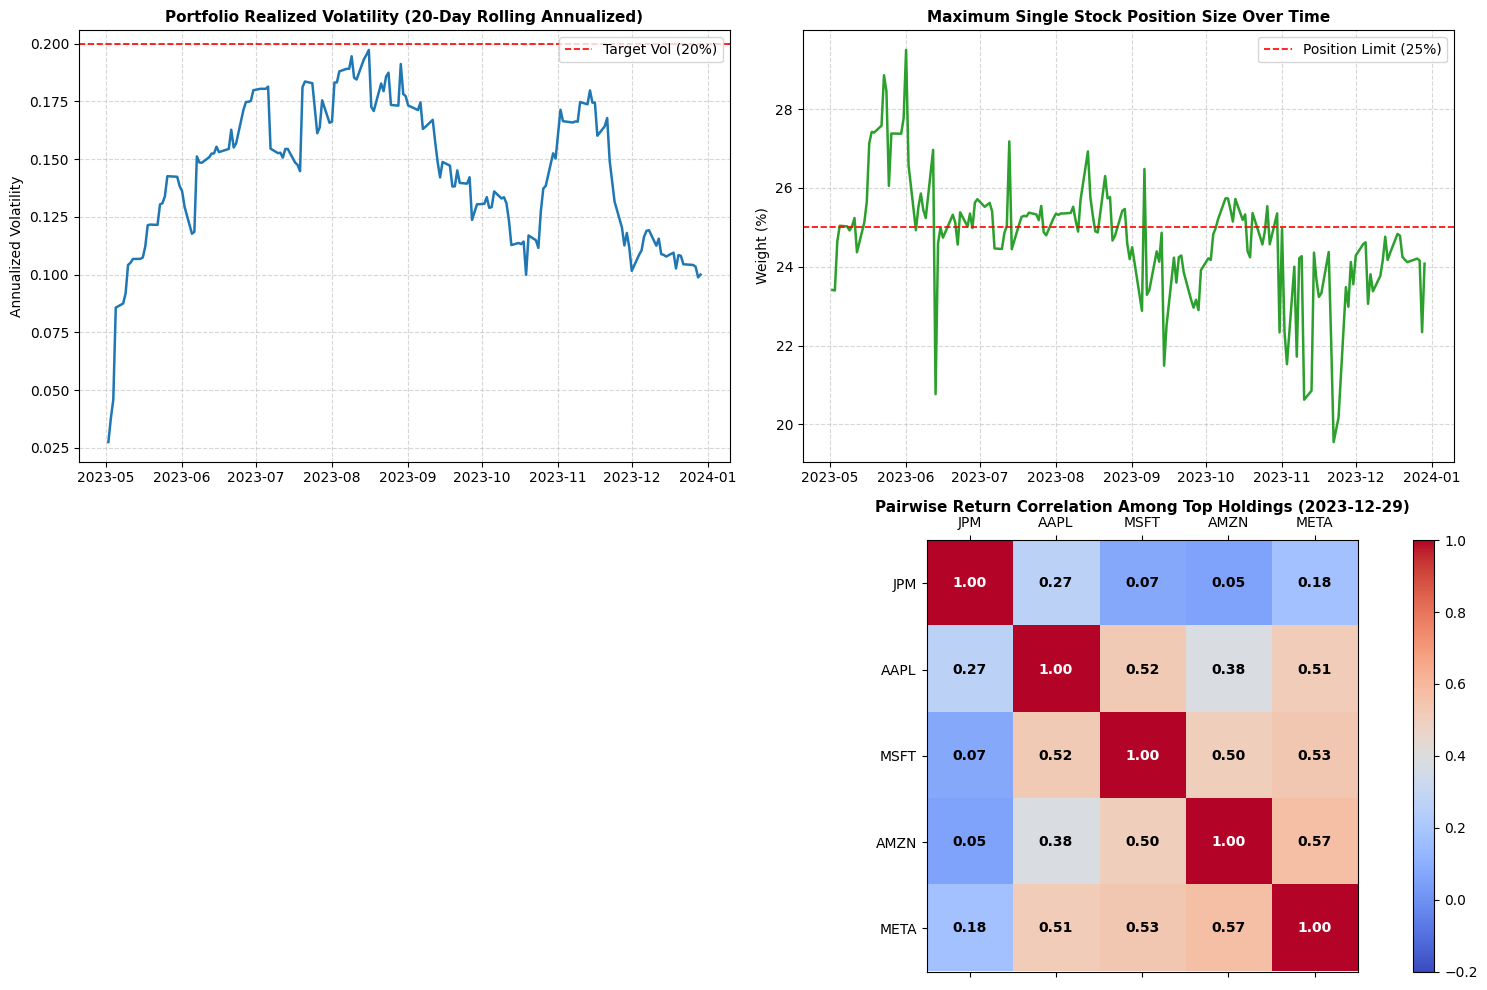

In [7]:
import matplotlib.pyplot as plt

# We compute daily portfolio return:
portfolio_df["Weighted_Return"] = portfolio_df["Weight"] * portfolio_df["Return_1d"]
daily_port_return = portfolio_df.groupby("Date")["Weighted_Return"].sum()

# 20-day rolling annualized volatility:
rolling_port_vol = daily_port_return.rolling(20).std() * np.sqrt(252)

# We track maximum position size over time:
max_weight_ts = portfolio_df.groupby("Date")["Weight"].max()

# We calculate correlation between top holdings on the latest date:
latest_top_5 = portfolio_df.xs(latest_date, level="Date").sort_values("Weight", ascending=False).head(5).index.tolist()
returns_wide = portfolio_df["Return_1d"].unstack(level="Ticker")
top_5_corr = returns_wide[latest_top_5].corr()

# Create diagnostic dashboard:
fig = plt.figure(figsize=(15, 10))

# Plot 1: Portfolio Volatility Over Time
ax1 = plt.subplot(2, 2, 1)
ax1.plot(rolling_port_vol.index, rolling_port_vol.values, color="#1f77b4", linewidth=1.8)
ax1.axhline(0.20, color="red", linestyle="dashed", linewidth=1.2, label="Target Vol (20%)")
ax1.set_title("Portfolio Realized Volatility (20-Day Rolling Annualized)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Annualized Volatility")
ax1.grid(True, linestyle="dashed", alpha=0.5)
ax1.legend(loc="upper right")

# Plot 2: Maximum Position Size Over Time
ax2 = plt.subplot(2, 2, 2)
ax2.plot(max_weight_ts.index, max_weight_ts.values * 100, color="#2ca02c", linewidth=1.8)
ax2.axhline(25.0, color="red", linestyle="dashed", linewidth=1.2, label="Position Limit (25%)")
ax2.set_title("Maximum Single Stock Position Size Over Time", fontsize=11, fontweight="bold")
ax2.set_ylabel("Weight (%)")
ax2.grid(True, linestyle="dashed", alpha=0.5)
ax2.legend(loc="upper right")

# Plot 3: Correlation Heatmap Between Top Holdings
ax3 = plt.subplot(2, 1, 2)
cax = ax3.matshow(top_5_corr, cmap="coolwarm", vmin=-0.2, vmax=1.0)
fig.colorbar(cax, ax=ax3, fraction=0.03, pad=0.04)

ax3.set_xticks(range(len(latest_top_5)))
ax3.set_yticks(range(len(latest_top_5)))
ax3.set_xticklabels(latest_top_5, fontsize=10)
ax3.set_yticklabels(latest_top_5, fontsize=10)

for i in range(len(latest_top_5)):
    for j in range(len(latest_top_5)):
        val = top_5_corr.iloc[i, j]
        color = "white" if val > 0.6 else "black"
        ax3.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontweight="bold")

ax3.set_title(f"Pairwise Return Correlation Among Top Holdings ({latest_date.strftime('%Y-%m-%d')})", pad=20, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# Let's inspect our average risk metrics:
print(f"Average Realized Portfolio Volatility: {rolling_port_vol.mean():.2%}")
print(f"Average Maximum Position Size:         {max_weight_ts.mean():.2%}")

---

## Practice Time

Now it is your turn to experiment with position sizing rules and risk constraints. Work through the three challenges below.

---

### Challenge 1: Expanding to a 10-Stock Portfolio
Modify `equal_weights()` to select the **top 10 stocks** instead of five. Apply this to our universe and print the allocations on the latest date. Verify what weight each stock receives when all available assets are included.

---

### Challenge 2: Enforcing a Strict 15% Position Cap
Run `portfolio_weights()` using a strict maximum position limit of `max_weight=0.15` (15%) with `top_n=5`. Print the resulting weights on the latest date and observe how the tighter ceiling redistributes excess capital across holdings.

---

### Challenge 3: Mid-Year Correlation Analysis
Calculate the correlation matrix between the top five holdings on the mid-year date: `2023-06-30`. Identify the pair with the lowest correlation and note why holding them together improves portfolio stability.

In [8]:
# Challenge 1: Equal weights for top 10 stocks
# Write your code below this line:



In [9]:
# Challenge 2: Maximum position limit of 15%
# Write your code below this line:



In [10]:
# Challenge 3: Correlation among top 5 holdings as of 2023-06-30
# Write your code below this line:



---

## Solutions

Compare your answers with the reference implementations below whenever you are ready.

### Solution for Challenge 1

In [11]:
# Solution for Challenge 1:
df_eq_10 = equal_weights(df, top_n=10)
latest_10 = df_eq_10.xs(latest_date, level="Date")

# Let's inspect the 10-stock weights:
print("Challenge 1 Output - Top 10 Equal Weights:")
print(latest_10[["Close", "Alpha_Rank", "Weight"]])

Exercise 1 Output - Top 10 Equal Weights:
Price        Close  Alpha_Rank  Weight
Ticker                                
AAPL    190.211014         0.7     0.1
AMZN    151.940002         1.0     0.1
GOOGL   138.462219         0.3     0.1
JNJ     145.083893         0.2     0.1
JPM     160.411087         0.8     0.1
META    350.878754         0.6     0.1
MSFT    368.179901         0.9     0.1
NVDA     49.434139         0.5     0.1
TSLA    248.479996         0.1     0.1
XOM      91.425262         0.4     0.1

In [12]:
# Solution for Challenge 2:
df_capped_15 = portfolio_weights(df, top_n=5, target_vol=0.2, max_weight=0.15)
latest_15 = df_capped_15.xs(latest_date, level="Date").sort_values("Weight", ascending=False)

# Let's inspect the capped portfolio weights:
print("Challenge 2 Output - Weights with 15% Position Cap:")
print(latest_15[["Close", "Realized_Vol", "Weight"]].head(6))

Exercise 2 Output - Weights with 15% Position Cap:
Price        Close  Realized_Vol    Weight
Ticker                                    
AAPL    190.211014      0.009078  0.175074
JPM     160.411087      0.006927  0.175074
MSFT    368.179901      0.009207  0.175074
AMZN    151.940002      0.011946  0.170374
META    350.878754      0.014566  0.139729
NVDA     49.434139      0.017250  0.117988

In [13]:
# Solution for Challenge 3:
target_date = "2023-06-30"
top_5_midyear = portfolio_df.xs(target_date, level="Date").sort_values("Weight", ascending=False).head(5).index.tolist()
midyear_corr = returns_wide.loc[:target_date, top_5_midyear].tail(60).corr()

print(f"Top 5 Holdings on {target_date}: {top_5_midyear}")

# Let's inspect the trailing correlation matrix:
print("\nChallenge 3 Output - Correlation Matrix (Trailing 60 Days):")
print(midyear_corr.round(3))

Top 5 Holdings on 2023-06-30: ['JNJ', 'AAPL', 'GOOGL', 'META', 'AMZN']

Exercise 3 Output - Correlation Matrix (Trailing 60 Days):
Ticker    JNJ   AAPL  GOOGL   META   AMZN
Ticker                                   
JNJ     1.000  0.108  0.067 -0.027 -0.018
AAPL    0.108  1.000  0.464  0.554  0.557
GOOGL   0.067  0.464  1.000  0.535  0.522
META   -0.027  0.554  0.535  1.000  0.522
AMZN   -0.018  0.557  0.522  0.522  1.000